# Chlorophyll Final Concatination

Now that all chlorophyllnmeasurments have been standardized and QA/QC'ed, it's time to combine into a single chlorophll dataset. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
from datetime import datetime
import os
from matplotlib import ticker
import datetime as dt
import plotly.express as px
import cmocean as cm
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import time
import matplotlib.ticker as mticker

# Chlorophyll

In [2]:
CalCOFI = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\calcofi_chl_qc.xlsx')
CalCOFI = CalCOFI.rename(columns={'identifier_product_doi':'DOI_url'})
CalCOFI['experiment']='CalCOFI'
CalCOFI['affiliations']='NOAA Fisheries, Scripps, CDFW'
CalCOFI['data_type']='bottle'

In [3]:
gloria_chl = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\GLORIA_chl_na.xlsx')
gloria_chl['datetime'] = pd.to_datetime(gloria_chl['datetime'])

The SeaBASS data set includes some repeated CalCOFI and GLORIA data. To ensure all datasets remain cohesive, remove any datapoints with identical datetime, lat, lon, and depth to these projects. 

In [4]:
seabass = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\SB_chl_na.xlsx')
seabass = seabass.rename(columns={'identifier_product_doi':'DOI_url','decision':'data_type_flag'})

#remove repeated calcofi data
sb_calc = CalCOFI[['datetime', 'lat', 'lon','depth']] #reduce to datetime, lat, lon, and depth for  matching
seabass['depth'] =seabass['depth'].astype('int64') #to match datatype of calcofi
#merge the two dataframes on similar columns
seabass = seabass.merge(sb_calc[['datetime', 'lat', 'lon','depth']], on=['datetime', 'lat', 'lon','depth'], how='left', indicator=True) #all calcofi data with seabass indicator
seabass =  seabass[seabass['_merge'] != 'both'] #remove rows where _merge has both
seabass=seabass[['datetime', 'lat', 'lon', 'chl', 'chl_a', 'depth', 'experiment', 'data_type', 'station', 'affiliations', 'investigators', 'contact',
       'cruise', 'DOI_url', 'HPLC', 'triplicate', 'data_type_flag']]
seabass['source']='SeaBASS'

#now that calcofi data has been removed, remove any repeated gloria data
gloria_sb = gloria_chl[gloria_chl['DOI_url'] !='https://doi.pangaea.de/10.1594/PANGAEA.948492'] #remove any data without seabass doi
gloria_sb=gloria_sb.rename(columns={"DOI_url": "doi_url"}) #temporary doi to match seabass temporary doi 
gloria_sb=gloria_sb[['datetime', 'depth','doi_url','lat', 'lon','chl']]

seabass['datetime'] = pd.to_datetime(seabass['datetime'])
seabass_test=seabass.copy()
seabass_test['doi_url'] = seabass_test['DOI_url'].str.lower() #all lowercase to match with gloria naming convention 

test2 = pd.merge(gloria_sb, seabass_test, on=['datetime', 'doi_url','lat', 'lon','chl'], how='right',indicator=True).reset_index(drop=True)
seabass1 =  test2[test2['_merge'] != 'both'] #remove rows where _merge has both
seabass1 = seabass1[['datetime', 'lat', 'lon', 'chl', 'chl_a', 'depth_y', 'experiment', 'data_type', 'station', 'affiliations', 'investigators', 'contact',
      'source', 'cruise', 'DOI_url', 'HPLC', 'triplicate', 'data_type_flag']]
seabass = seabass1.rename(columns={'depth_y':'depth'})

KeyboardInterrupt: 

In [ ]:
# 2025 seabass data 
seabass2 = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\SB_chl_2025.xlsx')
seabass2 = seabass2.rename(columns={'decision':'data_type_flag'})
seabass2=seabass2[['datetime', 'lat', 'lon', 'chl', 'chl_a', 'depth', 'experiment', 'data_type', 'station', 'affiliations', 'investigators', 'cruise', 
                   'HPLC', 'triplicate', 'data_type_flag']]
seabass2['source']='SeaBASS'

Now that SeaBASS data is completed, we can move on to the rest of the chlorophyll datasets

In [ ]:
HOTS = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\hots_chl_qc.xlsx')
HOTS = HOTS.rename(columns={'url':'DOI_url'})
HOTS['data_type']='bottle'

In [ ]:
IOOS = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\ioos_chl_qc2.xlsx')
IOOS = IOOS.rename(columns={'url':'DOI_url','Institution':'affiliations','date':'datetime','decision':'data_type_flag'})
IOOS=IOOS[['datetime', 'lat', 'lon', 'chl', 'depth', 'source', 'affiliations', 'DOI_url', 'experiment', 'HPLC', 'triplicate','data_type_flag']] 
IOOS = IOOS[IOOS['datetime'] <= '2026-01-01'] #only keep 2025 data
#remove 'Dataset ID' since repeat of experiment 

In [ ]:
bco = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\bco_dmo_chl_qc.xlsx')
bco = bco.rename(columns={'url':'DOI_url'})

In [ ]:
#wod doesn't always have experiment, but always has accession number i.e. NODC accession number so use that instead 
wod = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\wod_chl_na.xlsx')
wod['source'] = 'WOD'
wod['DOI_url'] = 'https://www.ncei.noaa.gov/access/world-ocean-database-select/dbsearch.html'
wod=wod[['datetime', 'lat', 'lon', 'chl', 'depth', 'cruise','affiliations', 'source','investigators', 'HPLC', 'triplicate','decision', 'accession number']]
wod = wod.rename(columns={'accession number':'experiment','decision':'data_type_flag'})

In [ ]:
aqua = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\aquamatch_chl_na.xlsx')
aqua = aqua.rename(columns={'url':'DOI_url'})
aqua['experiment']='AquaMatch'

In [ ]:
globec = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\globec_chl_qc.xlsx')
globec = globec.rename(columns={'url':'DOI_url'})

In [ ]:
seamap = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\seamap_chl.xlsx')
seamap = seamap.dropna(subset=['depth'])
seamap = seamap[['datetime', 'lat', 'lon', 'chl','station','cruise', 'depth','source', 'DOI_url', 'experiment', 'investigators',
       'affiliations', 'HPLC', 'triplicate']]

In [ ]:
arctic = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\arctic_pigment_chl.xlsx')
arctic = arctic.rename(columns={'url':'DOI_url','contact':'investigators','affiliation':'affiliations'})
arctic=arctic[['datetime', 'lat', 'lon', 'depth','chl_a', 'experiment', 'DOI_url', 'triplicate', 'HPLC', 'source', 'investigators', 'affiliations']]
arctic = arctic.dropna(subset=['depth'])
arctic = arctic.dropna(subset=['chl_a'])
arctic['source'] = 'Pan-Arctic'

In [ ]:
CIOOS = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\CIOOS_chl.xlsx')
CIOOS=CIOOS[['cruise', 'station', 'datetime', 'lat', 'lon', 'depth', 'chl', 'experiment', 'investigators', 'affiliations', 'DOI_url', 'HPLC',
       'triplicate', 'chl_a']]
CIOOS['source'] = 'CIOOS'

## Concatinate into Dataframe

In [ ]:
dfs=[seabass,seabass2,aqua,bco,CalCOFI,globec,HOTS,IOOS,wod,gloria_chl,seamap,arctic,CIOOS]
all_chl = pd.concat(dfs).reset_index(drop=True)
all_chl = all_chl.dropna(subset=['chl', 'chl_a'], how='all')
all_chl = all_chl.dropna(subset=['datetime'], how='all') #if no datetime, remove

Usually, HPLC chl is in the chl_a column. However, sometimes a project lables hplc chlorophyll as chl (NOT chl_a). 
So, to keep it consistant, 1. IF HPLC is flagged to True(0) and, 2. if chl_a is empty, THEN populate the chl_a column with the value in chl.
This way, we retain what the original data source says, but it makes the HPLC data more consistant.

In [ ]:
all_chl.loc[(all_chl['HPLC']== 0) & (all_chl['chl_a'].isnull()), 'chl_a'] = all_chl['chl']

In [ ]:
#remove all negative values from column
condition_A = (all_chl['chl'] >= 0) | (all_chl['chl'].isnull())
condition_B = (all_chl['chl_a'] >= 0) | (all_chl['chl_a'].isnull())
all_chl = all_chl[condition_A & condition_B]

Next, each row will have a unique ID code made from combining the source, experiemnt (with all special charecters removed), datetime, lat, lon, and depth

In [ ]:
#first, create a temporary column that has the xperiment names but without special charecters (_,-,',(,[)
all_chl['temp_exp'] = all_chl['experiment'].str.replace('_', '', regex=False)
all_chl['temp_exp'] = all_chl['temp_exp'].str.replace('-', '', regex=False)
all_chl['temp_exp'] = all_chl['temp_exp'].str.replace(' ', '', regex=False)
all_chl['temp_exp'] = all_chl['temp_exp'].str.replace('(', '', regex=False)
all_chl['temp_exp'] = all_chl['temp_exp'].str.replace(')', '', regex=False)
all_chl['temp_exp'] = all_chl['temp_exp'].str.replace('[', '', regex=False)
all_chl['temp_exp'] = all_chl['temp_exp'].str.replace(']', '', regex=False)

In [ ]:
all_chl['ID_code'] = all_chl['source'].astype(str) + '_' + all_chl['temp_exp'].astype(str) + '_' + all_chl['datetime'].dt.strftime('%Y%m%d-%H%M%S').astype(str) + '_' + all_chl['lat'].astype(str) + '_' + all_chl['lon'].astype(str) +'_' + all_chl['depth'].astype(str)+'m'
#add sequential sample number to repeated id tags
all_chl['ID_code'] = all_chl['ID_code'] + '_' + all_chl.groupby('ID_code').cumcount().astype(str)

In [ ]:
shp = gpd.read_file(r'C:\Users\gianna.milton\Documents\Python\Shapefiles\combined_coastline.shp')
gdf = gpd.GeoDataFrame(all_chl, geometry=gpd.points_from_xy(all_chl.lon, all_chl.lat), crs="EPSG:4269")
gdf = gdf.to_crs(shp.crs)
all_chl = gpd.sjoin(gdf, shp, how="inner", predicate="within")
columns_to_drop = ['geometry', 'index_right', 'merge_id']
all_chl = all_chl.drop(columns=columns_to_drop)
all_chl= all_chl.reset_index(drop=True)

In [ ]:
all_chl=all_chl[['ID_code','datetime', 'lat', 'lon', 'chl', 'chl_a', 'depth', 'experiment', 'station', 'affiliations', 'investigators', 'contact',
       'cruise', 'DOI_url', 'HPLC', 'triplicate', 'data_type_flag', 'source', 'cast']]

In [ ]:
#all_chl.to_excel('all_chl.xlsx', index = False)


All chlorophyll samples standardized and concatinated. 

# Plots and stats 

In [2]:
chl = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\all_chl.xlsx')

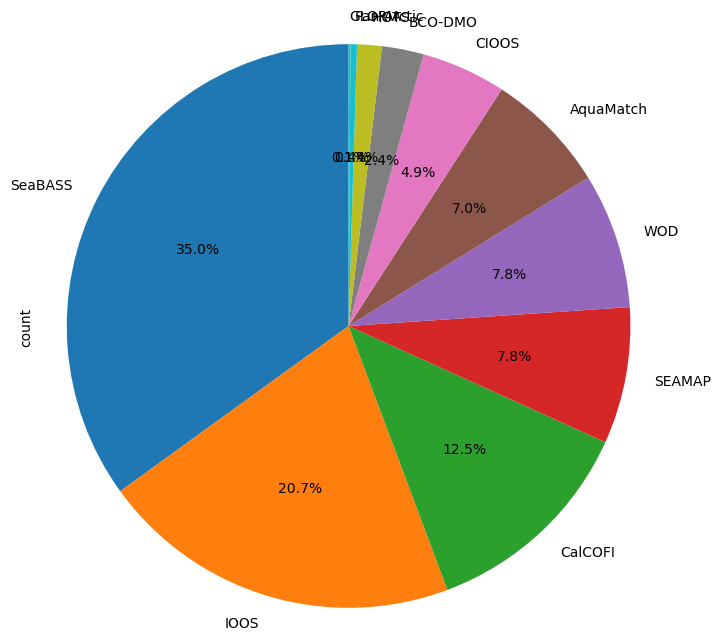

In [6]:
category_counts = chl['source'].value_counts() 
plt.figure(figsize=(8, 8)) # Optional: set the figure size
category_counts.plot.pie(autopct='%1.1f%%', startangle=90, cmap='tab10')
plt.axis('equal') 
plt.show()

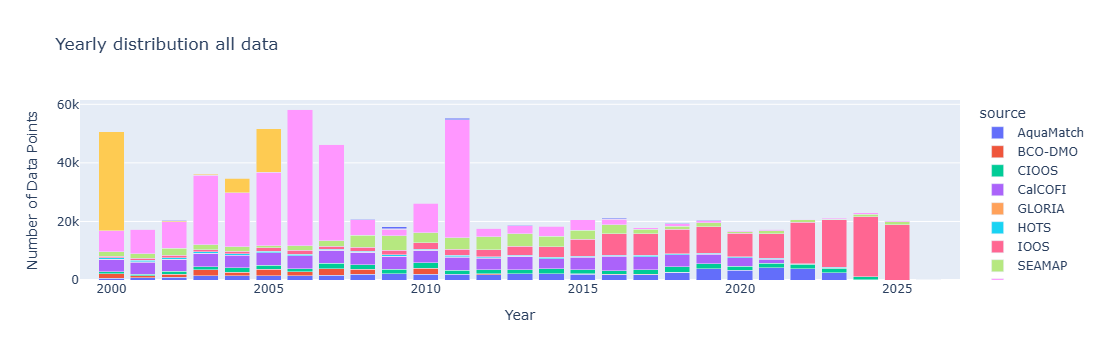

In [7]:
year_test=chl.copy()
year_test['datetime'] = pd.to_datetime(year_test['datetime'])
year_test['year'] = year_test['datetime'].dt.year
grouped = year_test.groupby(['year', 'source']).size().reset_index(name='DataPoints')

# Create bar chart
fig = px.bar(grouped, x='year', y='DataPoints', color='source', title='Yearly distribution all data',
    labels={'year': 'Year', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[1999,2027])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

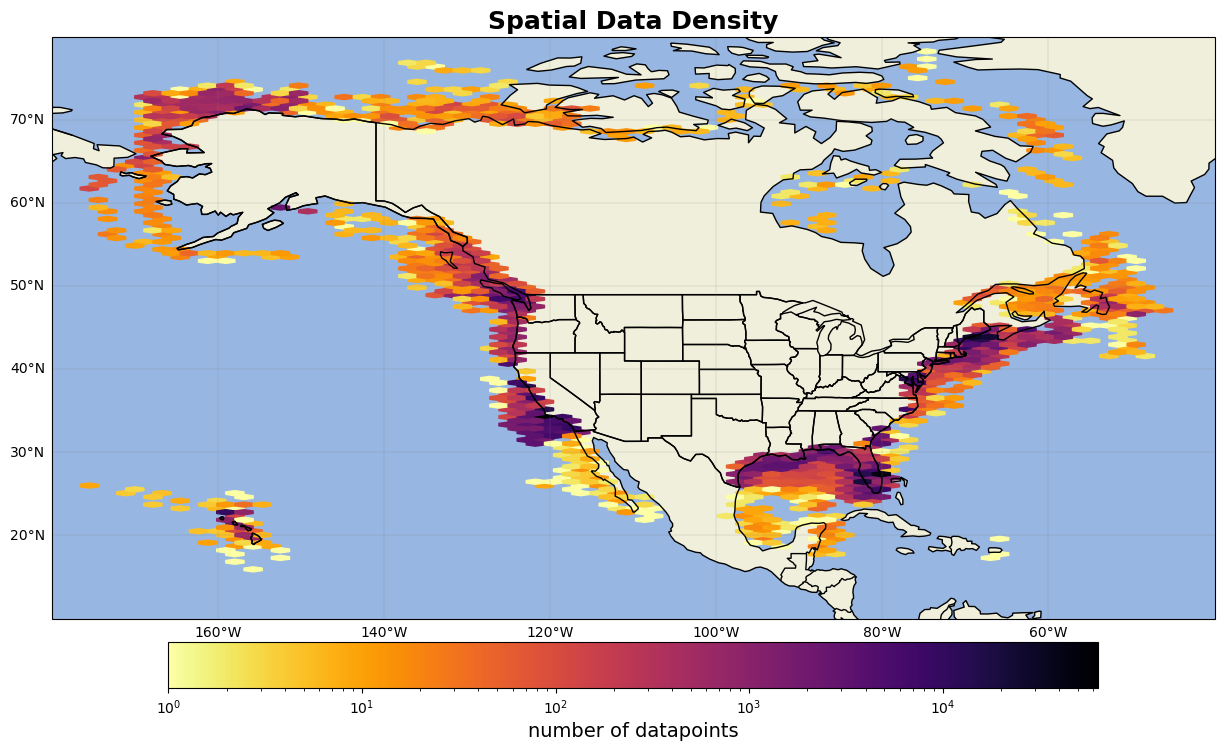

In [8]:
from matplotlib.colors import LogNorm # Important for high-variance data
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
hb = ax.hexbin(year_test.lon, year_test.lat, gridsize=150, cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) 
cb = plt.colorbar(hb, ax=ax, orientation='horizontal', pad=0.02, shrink=0.8)
cb.set_label('number of datapoints', fontsize=14)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
ax.set_extent([-180, -40, 10, 80], crs=ccrs.PlateCarree())

ax.set_title('Spatial Data Density', fontsize=18, fontweight='bold')

plt.show()